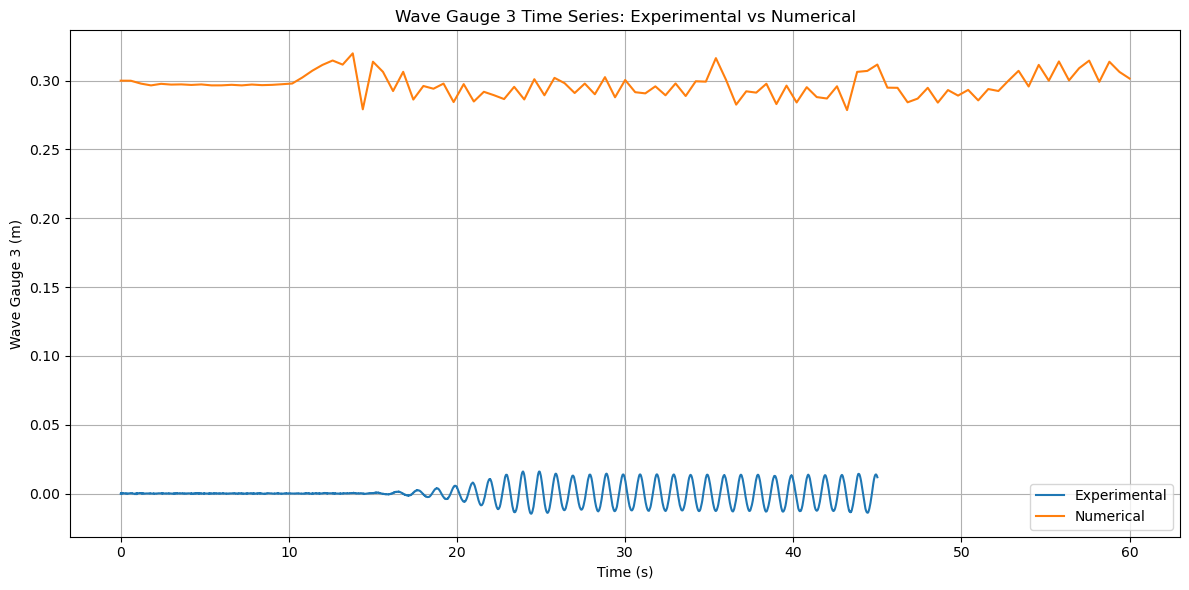

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WV_GAGE_3_numerical.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 3 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 3"]].copy()

# Rename columns for consistency
exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Convert to numeric and clean
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")

num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# Plot both time series
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 3 (m)")
plt.title("Wave Gauge 3 Time Series: Experimental vs Numerical")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.010438 m
MAE  = 0.007912 m
R    = 0.008098


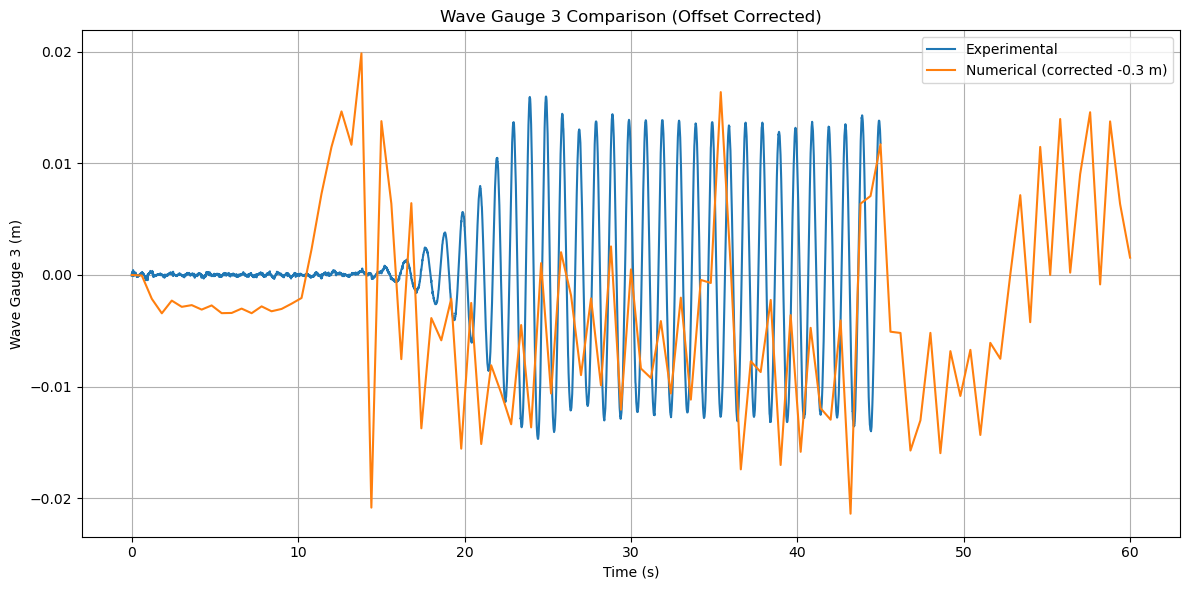

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WV_GAGE_3_numerical.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 3 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 3"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")

num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 3 (m)")
plt.title("Wave Gauge 3 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.011158 m
MAE  = 0.008620 m
R    = 0.074953


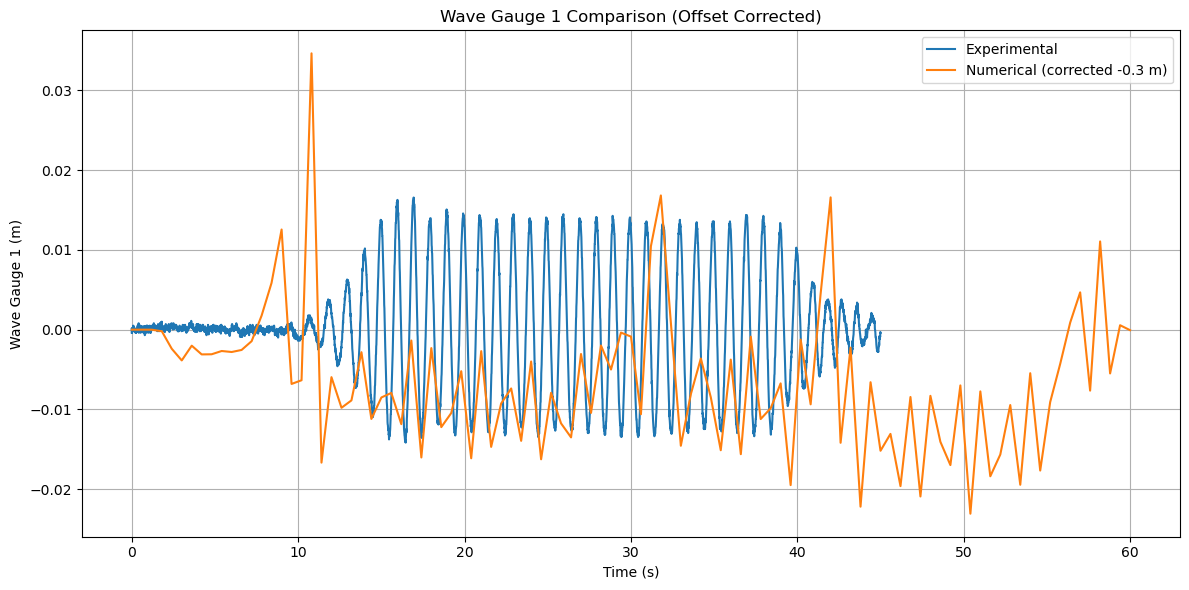

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WV_GAGE_1_numerical.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")

num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.016408 m
MAE  = 0.013134 m
R    = -0.327013


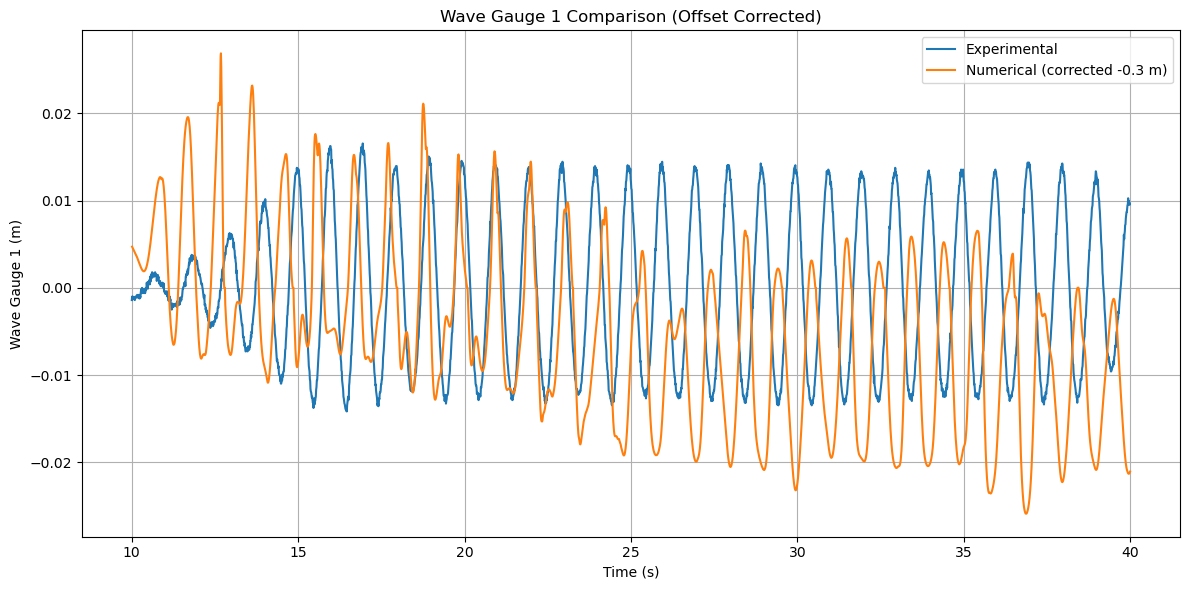

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.015816 m
MAE  = 0.012719 m
R    = -0.255151


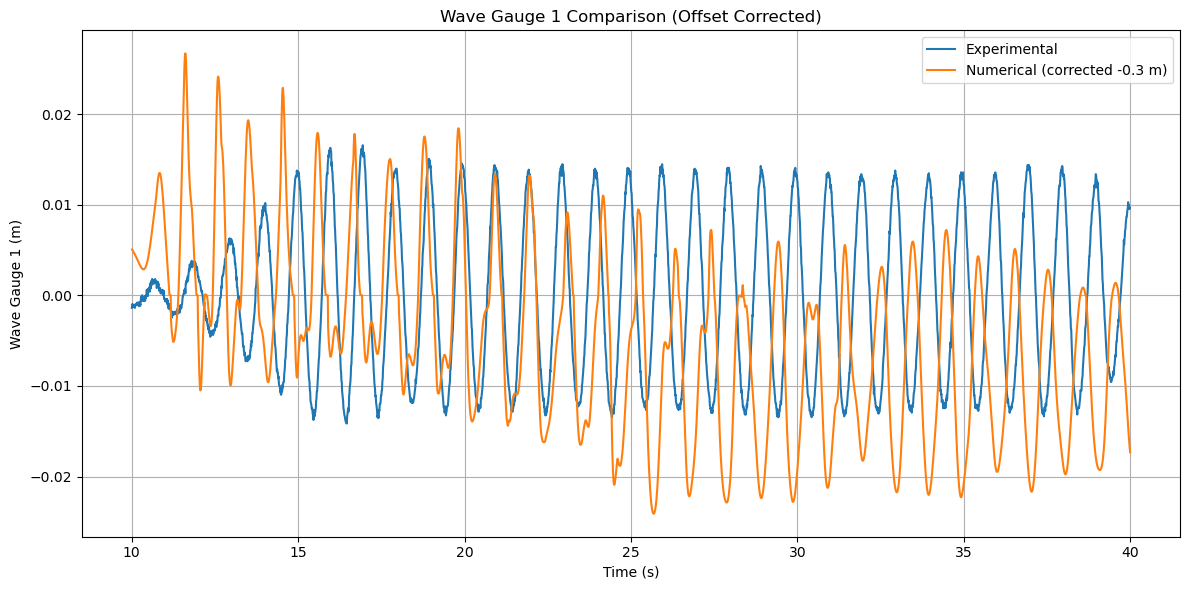

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.016724 m
MAE  = 0.013608 m
R    = -0.036247


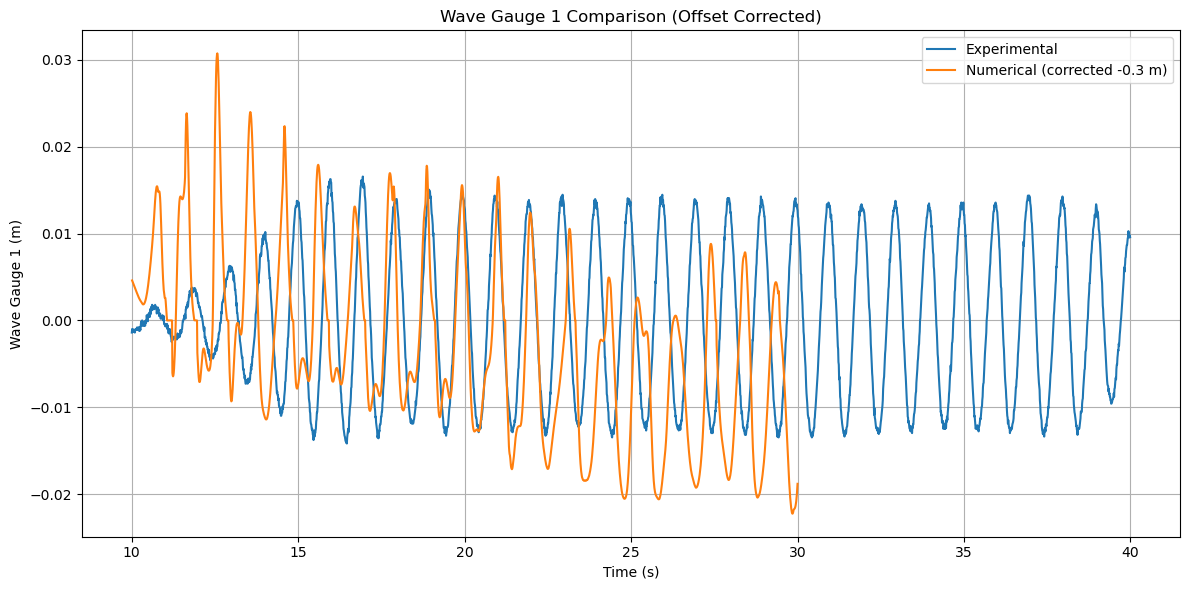

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_FLUME_WITH_REEF.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.015816 m
MAE  = 0.012719 m
R    = -0.255151


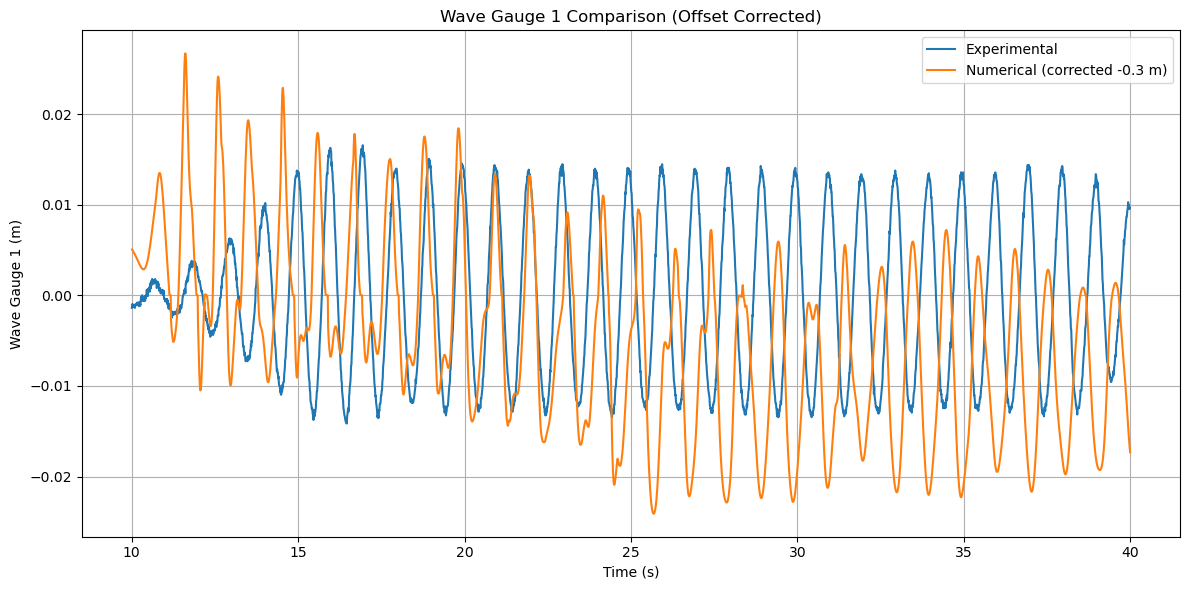

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.015755 m
MAE  = 0.012610 m
R    = -0.245599


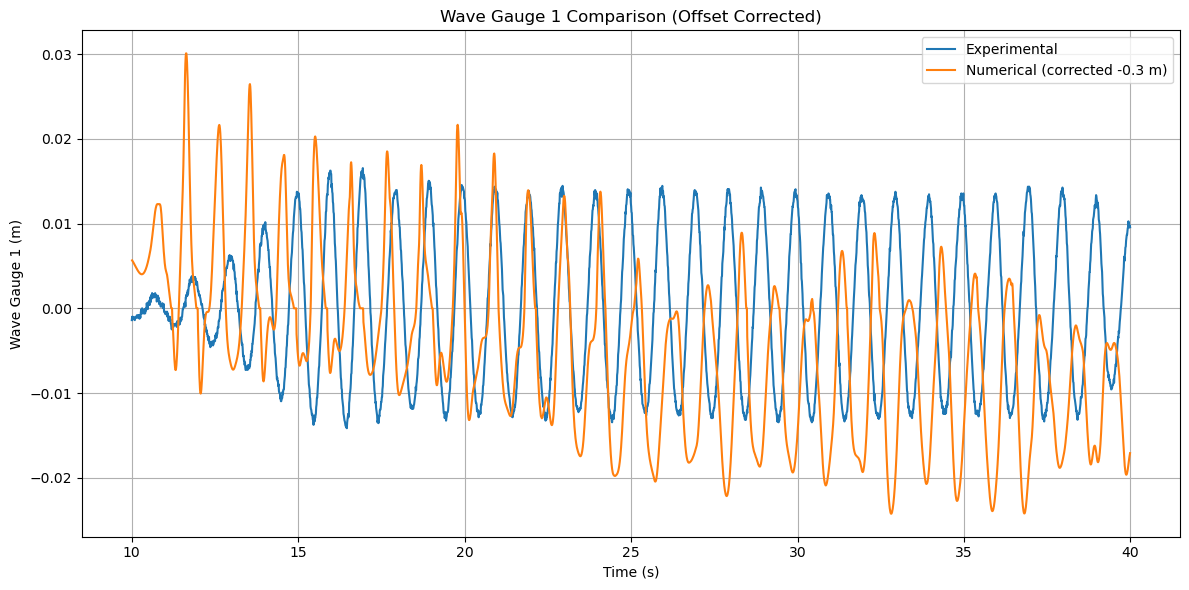

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V4_wave_length.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.008569 m
MAE  = 0.007244 m
R    = 0.257202


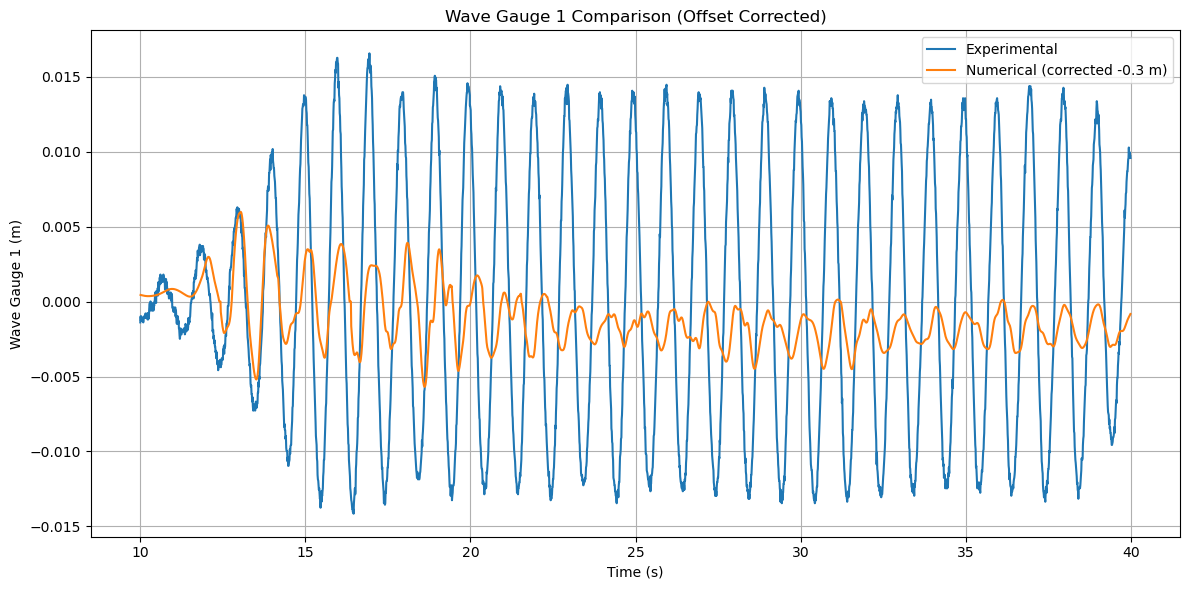

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V5_wave_length_elv0.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.015686 m
MAE  = 0.013703 m
R    = -0.561994


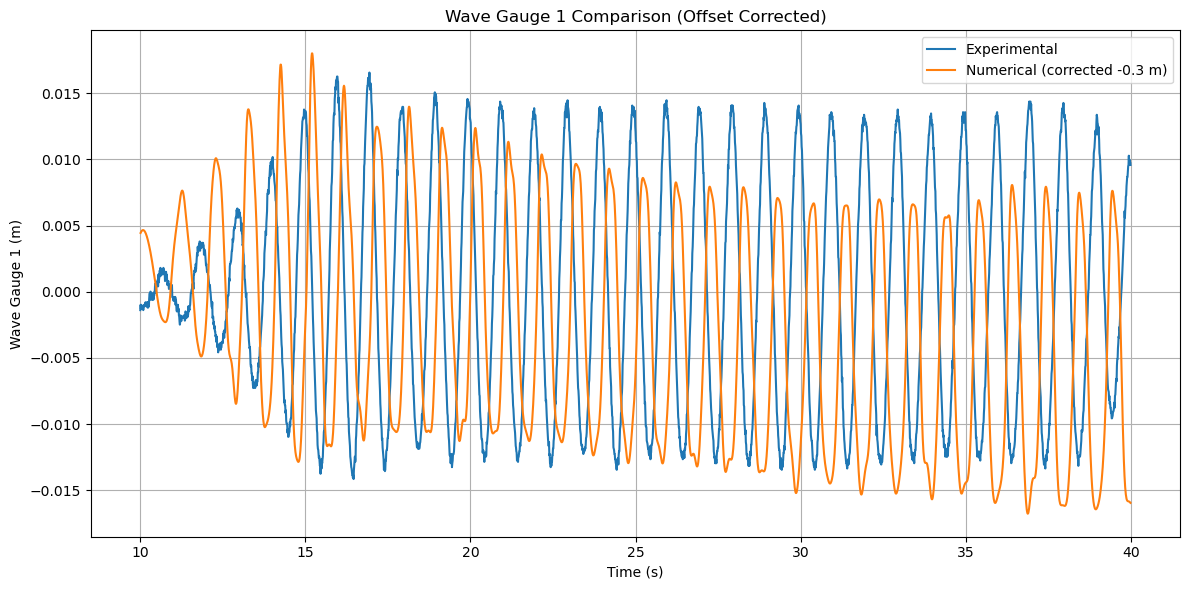

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V6_finemesh_.001.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 10) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 10) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

RMSE = 0.015134 m
MAE  = 0.013580 m
R    = -0.410111


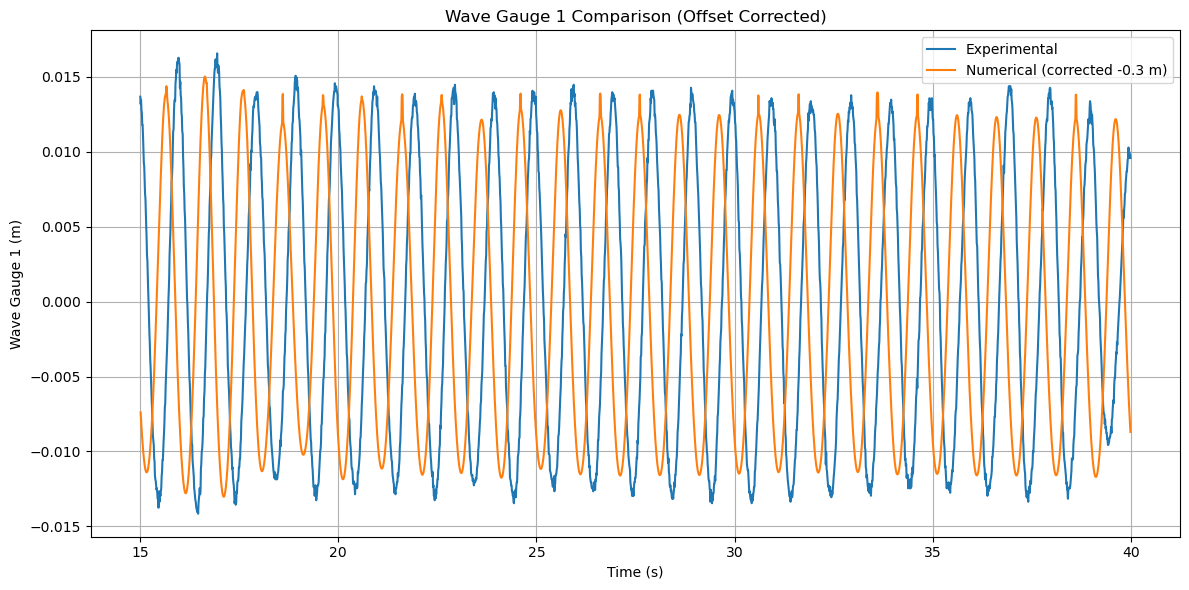

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_ONLY_FLUME_V7_variable_mesh.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")


num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# 🔴 APPLY OFFSET CORRECTION
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3
# -----------------------------
# ⏱️ FILTER TIME WINDOW (10–40 s)
# -----------------------------
exp_df = exp_df[(exp_df["Time"] >= 15) & (exp_df["Time"] <= 40)]
num_df = num_df[(num_df["Time"] >= 15) & (num_df["Time"] <= 40)]

# -----------------------------
# Interpolate numerical to experimental time
# -----------------------------
common_time = exp_df["Time"].values
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

comparison_df = pd.DataFrame({
    "Time": common_time,
    "Experimental": exp_df["Experimental"].values,
    "Numerical_interp": num_interp
})

# -----------------------------
# Metrics
# -----------------------------
rmse = np.sqrt(np.mean((comparison_df["Experimental"] - comparison_df["Numerical_interp"])**2))
mae = np.mean(np.abs(comparison_df["Experimental"] - comparison_df["Numerical_interp"]))
corr = np.corrcoef(comparison_df["Experimental"], comparison_df["Numerical_interp"])[0, 1]

print(f"RMSE = {rmse:.6f} m")
print(f"MAE  = {mae:.6f} m")
print(f"R    = {corr:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(exp_df["Time"], exp_df["Experimental"], label="Experimental", linewidth=1.5)
plt.plot(num_df["Time"], num_df["Numerical"], label="Numerical (corrected -0.3 m)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 1 (m)")
plt.title("Wave Gauge 1 Comparison (Offset Corrected)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best lag = -121 samples
Time shift applied to numerical = -1.2100 s
RMSE (phase-aligned) = 0.002606 m
MAE  (phase-aligned) = 0.002144 m
R    (phase-aligned) = 0.955064


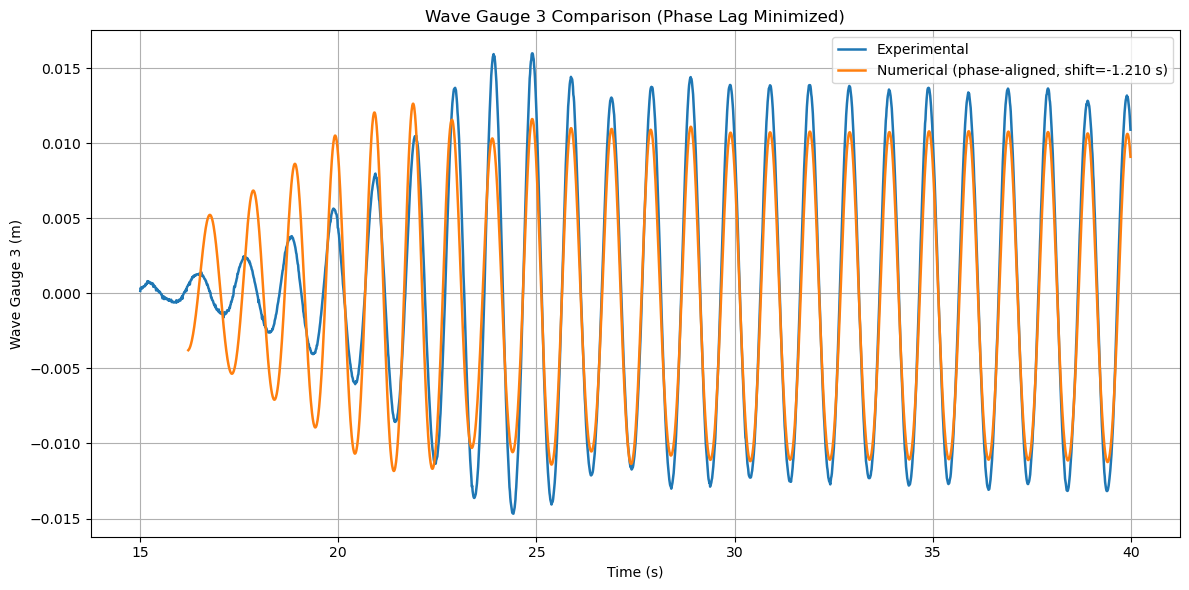

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 3 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 3"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")
num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# Offset correction
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Filter time window
# -----------------------------
t_min, t_max = 15, 40
exp_df = exp_df[(exp_df["Time"] >= t_min) & (exp_df["Time"] <= t_max)].copy()
num_df = num_df[(num_df["Time"] >= t_min) & (num_df["Time"] <= t_max)].copy()

# -----------------------------
# Interpolate both signals to a common uniform time grid
# -----------------------------
dt_exp = np.median(np.diff(exp_df["Time"].values))
dt_num = np.median(np.diff(num_df["Time"].values))
dt = min(dt_exp, dt_num)

common_time = np.arange(
    max(exp_df["Time"].min(), num_df["Time"].min()),
    min(exp_df["Time"].max(), num_df["Time"].max()),
    dt
)

exp_interp = np.interp(common_time, exp_df["Time"].values, exp_df["Experimental"].values)
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

# -----------------------------
# Remove mean before phase alignment
# -----------------------------
exp_demean = exp_interp - np.mean(exp_interp)
num_demean = num_interp - np.mean(num_interp)

# -----------------------------
# Find lag using cross-correlation
# Positive lag means numerical lags experimental
# -----------------------------
corr_full = np.correlate(num_demean, exp_demean, mode="full")
lags = np.arange(-len(exp_demean) + 1, len(exp_demean))
best_lag = lags[np.argmax(corr_full)]
time_shift = best_lag * dt

print(f"Best lag = {best_lag} samples")
print(f"Time shift applied to numerical = {time_shift:.4f} s")

# -----------------------------
# Shift numerical time to minimize phase lag
# If numerical lags, move it left by time_shift
# -----------------------------
shifted_num_time = num_df["Time"].values - time_shift

# Re-interpolate shifted numerical signal on experimental/common time
num_shifted_interp = np.interp(
    common_time,
    shifted_num_time,
    num_df["Numerical"].values,
    left=np.nan,
    right=np.nan
)

# Remove NaN edges after shifting
valid = ~np.isnan(num_shifted_interp)
common_time_valid = common_time[valid]
exp_valid = exp_interp[valid]
num_valid = num_shifted_interp[valid]

# -----------------------------
# Metrics after phase alignment
# -----------------------------
rmse = np.sqrt(np.mean((exp_valid - num_valid) ** 2))
mae = np.mean(np.abs(exp_valid - num_valid))
corr_coef = np.corrcoef(exp_valid, num_valid)[0, 1]

print(f"RMSE (phase-aligned) = {rmse:.6f} m")
print(f"MAE  (phase-aligned) = {mae:.6f} m")
print(f"R    (phase-aligned) = {corr_coef:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(common_time, exp_interp, label="Experimental", linewidth=1.8)
plt.plot(common_time_valid, num_valid, label=f"Numerical (phase-aligned, shift={time_shift:.3f} s)", linewidth=1.8)

plt.xlabel("Time (s)")
plt.ylabel("Wave Gauge 3 (m)")
plt.title("Wave Gauge 3 Comparison (Phase Lag Minimized)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best lag = 49 samples
Time shift applied to numerical = 0.4900 s
RMSE (phase-aligned) = 0.001728 m
MAE  (phase-aligned) = 0.001442 m
R    (phase-aligned) = 0.993490


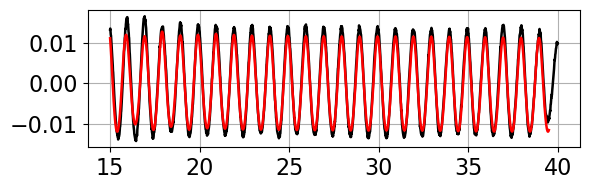

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 1 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 1"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")
num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# Offset correction
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Filter time window
# -----------------------------
t_min, t_max = 15, 40
exp_df = exp_df[(exp_df["Time"] >= t_min) & (exp_df["Time"] <= t_max)].copy()
num_df = num_df[(num_df["Time"] >= t_min) & (num_df["Time"] <= t_max)].copy()

# -----------------------------
# Interpolate both signals to a common uniform time grid
# -----------------------------
dt_exp = np.median(np.diff(exp_df["Time"].values))
dt_num = np.median(np.diff(num_df["Time"].values))
dt = min(dt_exp, dt_num)

common_time = np.arange(
    max(exp_df["Time"].min(), num_df["Time"].min()),
    min(exp_df["Time"].max(), num_df["Time"].max()),
    dt
)

exp_interp = np.interp(common_time, exp_df["Time"].values, exp_df["Experimental"].values)
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

# -----------------------------
# Remove mean before phase alignment
# -----------------------------
exp_demean = exp_interp - np.mean(exp_interp)
num_demean = num_interp - np.mean(num_interp)

# -----------------------------
# Find lag using cross-correlation
# Positive lag means numerical lags experimental
# -----------------------------
corr_full = np.correlate(num_demean, exp_demean, mode="full")
lags = np.arange(-len(exp_demean) + 1, len(exp_demean))
best_lag = lags[np.argmax(corr_full)]
time_shift = best_lag * dt

print(f"Best lag = {best_lag} samples")
print(f"Time shift applied to numerical = {time_shift:.4f} s")

# -----------------------------
# Shift numerical time to minimize phase lag
# If numerical lags, move it left by time_shift
# -----------------------------
shifted_num_time = num_df["Time"].values - time_shift

# Re-interpolate shifted numerical signal on experimental/common time
num_shifted_interp = np.interp(
    common_time,
    shifted_num_time,
    num_df["Numerical"].values,
    left=np.nan,
    right=np.nan
)

# Remove NaN edges after shifting
valid = ~np.isnan(num_shifted_interp)
common_time_valid = common_time[valid]
exp_valid = exp_interp[valid]
num_valid = num_shifted_interp[valid]

# -----------------------------
# Metrics after phase alignment
# -----------------------------
rmse = np.sqrt(np.mean((exp_valid - num_valid) ** 2))
mae = np.mean(np.abs(exp_valid - num_valid))
corr_coef = np.corrcoef(exp_valid, num_valid)[0, 1]

print(f"RMSE (phase-aligned) = {rmse:.6f} m")
print(f"MAE  (phase-aligned) = {mae:.6f} m")
print(f"R    (phase-aligned) = {corr_coef:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 2))
plt.plot(common_time, exp_interp, color = 'black', linewidth=1.8)
plt.plot(common_time_valid, num_valid, color = 'red', linewidth=1.8)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.xlabel("Time (s)")
# plt.ylabel("Wave Gauge 3 (m)")
# plt.title("Wave Gauge 3 Comparison (Phase Lag Minimized)")
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best lag = -62 samples
Time shift applied to numerical = -0.6200 s
RMSE (phase-aligned) = 0.001782 m
MAE  (phase-aligned) = 0.001489 m
R    (phase-aligned) = 0.993121


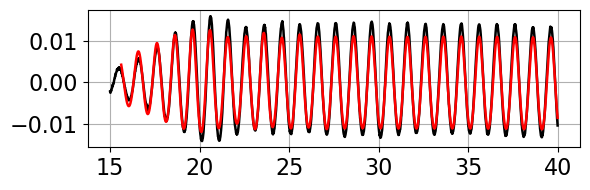

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 2 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 2"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")
num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# Offset correction
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Filter time window
# -----------------------------
t_min, t_max = 15, 40
exp_df = exp_df[(exp_df["Time"] >= t_min) & (exp_df["Time"] <= t_max)].copy()
num_df = num_df[(num_df["Time"] >= t_min) & (num_df["Time"] <= t_max)].copy()

# -----------------------------
# Interpolate both signals to a common uniform time grid
# -----------------------------
dt_exp = np.median(np.diff(exp_df["Time"].values))
dt_num = np.median(np.diff(num_df["Time"].values))
dt = min(dt_exp, dt_num)

common_time = np.arange(
    max(exp_df["Time"].min(), num_df["Time"].min()),
    min(exp_df["Time"].max(), num_df["Time"].max()),
    dt
)

exp_interp = np.interp(common_time, exp_df["Time"].values, exp_df["Experimental"].values)
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

# -----------------------------
# Remove mean before phase alignment
# -----------------------------
exp_demean = exp_interp - np.mean(exp_interp)
num_demean = num_interp - np.mean(num_interp)

# -----------------------------
# Find lag using cross-correlation
# Positive lag means numerical lags experimental
# -----------------------------
corr_full = np.correlate(num_demean, exp_demean, mode="full")
lags = np.arange(-len(exp_demean) + 1, len(exp_demean))
best_lag = lags[np.argmax(corr_full)]
time_shift = best_lag * dt

print(f"Best lag = {best_lag} samples")
print(f"Time shift applied to numerical = {time_shift:.4f} s")

# -----------------------------
# Shift numerical time to minimize phase lag
# If numerical lags, move it left by time_shift
# -----------------------------
shifted_num_time = num_df["Time"].values - time_shift

# Re-interpolate shifted numerical signal on experimental/common time
num_shifted_interp = np.interp(
    common_time,
    shifted_num_time,
    num_df["Numerical"].values,
    left=np.nan,
    right=np.nan
)

# Remove NaN edges after shifting
valid = ~np.isnan(num_shifted_interp)
common_time_valid = common_time[valid]
exp_valid = exp_interp[valid]
num_valid = num_shifted_interp[valid]

# -----------------------------
# Metrics after phase alignment
# -----------------------------
rmse = np.sqrt(np.mean((exp_valid - num_valid) ** 2))
mae = np.mean(np.abs(exp_valid - num_valid))
corr_coef = np.corrcoef(exp_valid, num_valid)[0, 1]

print(f"RMSE (phase-aligned) = {rmse:.6f} m")
print(f"MAE  (phase-aligned) = {mae:.6f} m")
print(f"R    (phase-aligned) = {corr_coef:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 2))
plt.plot(common_time, exp_interp, color = 'black', linewidth=1.8)
plt.plot(common_time_valid, num_valid, color = 'red', linewidth=1.8)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.xlabel("Time (s)")
# plt.ylabel("Wave Gauge 3 (m)")
# plt.title("Wave Gauge 3 Comparison (Phase Lag Minimized)")
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best lag = -121 samples
Time shift applied to numerical = -1.2100 s
RMSE (phase-aligned) = 0.002606 m
MAE  (phase-aligned) = 0.002144 m
R    (phase-aligned) = 0.955064


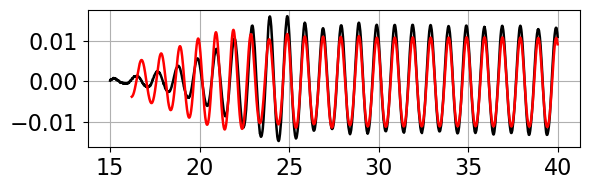

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
exp_file = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"
num_file = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

# -----------------------------
# Read Excel files
# -----------------------------
exp_df = pd.read_excel(exp_file)
num_df = pd.read_excel(num_file)

# -----------------------------
# Select required columns
# -----------------------------
exp_df = exp_df[["Time (s)", "Wave gauge 3 (m)"]].copy()
num_df = num_df[["TIME", "WAVE GAGE 3"]].copy()

exp_df.columns = ["Time", "Experimental"]
num_df.columns = ["Time", "Numerical"]

# -----------------------------
# Clean data
# -----------------------------
exp_df["Time"] = pd.to_numeric(exp_df["Time"], errors="coerce")
exp_df["Experimental"] = pd.to_numeric(exp_df["Experimental"], errors="coerce")
num_df["Time"] = pd.to_numeric(num_df["Time"], errors="coerce")
num_df["Numerical"] = pd.to_numeric(num_df["Numerical"], errors="coerce")

exp_df = exp_df.dropna().sort_values("Time")
num_df = num_df.dropna().sort_values("Time")

# -----------------------------
# Offset correction
# -----------------------------
num_df["Numerical"] = num_df["Numerical"] - 0.3

# -----------------------------
# Filter time window
# -----------------------------
t_min, t_max = 15, 40
exp_df = exp_df[(exp_df["Time"] >= t_min) & (exp_df["Time"] <= t_max)].copy()
num_df = num_df[(num_df["Time"] >= t_min) & (num_df["Time"] <= t_max)].copy()

# -----------------------------
# Interpolate both signals to a common uniform time grid
# -----------------------------
dt_exp = np.median(np.diff(exp_df["Time"].values))
dt_num = np.median(np.diff(num_df["Time"].values))
dt = min(dt_exp, dt_num)

common_time = np.arange(
    max(exp_df["Time"].min(), num_df["Time"].min()),
    min(exp_df["Time"].max(), num_df["Time"].max()),
    dt
)

exp_interp = np.interp(common_time, exp_df["Time"].values, exp_df["Experimental"].values)
num_interp = np.interp(common_time, num_df["Time"].values, num_df["Numerical"].values)

# -----------------------------
# Remove mean before phase alignment
# -----------------------------
exp_demean = exp_interp - np.mean(exp_interp)
num_demean = num_interp - np.mean(num_interp)

# -----------------------------
# Find lag using cross-correlation
# Positive lag means numerical lags experimental
# -----------------------------
corr_full = np.correlate(num_demean, exp_demean, mode="full")
lags = np.arange(-len(exp_demean) + 1, len(exp_demean))
best_lag = lags[np.argmax(corr_full)]
time_shift = best_lag * dt

print(f"Best lag = {best_lag} samples")
print(f"Time shift applied to numerical = {time_shift:.4f} s")

# -----------------------------
# Shift numerical time to minimize phase lag
# If numerical lags, move it left by time_shift
# -----------------------------
shifted_num_time = num_df["Time"].values - time_shift

# Re-interpolate shifted numerical signal on experimental/common time
num_shifted_interp = np.interp(
    common_time,
    shifted_num_time,
    num_df["Numerical"].values,
    left=np.nan,
    right=np.nan
)

# Remove NaN edges after shifting
valid = ~np.isnan(num_shifted_interp)
common_time_valid = common_time[valid]
exp_valid = exp_interp[valid]
num_valid = num_shifted_interp[valid]

# -----------------------------
# Metrics after phase alignment
# -----------------------------
rmse = np.sqrt(np.mean((exp_valid - num_valid) ** 2))
mae = np.mean(np.abs(exp_valid - num_valid))
corr_coef = np.corrcoef(exp_valid, num_valid)[0, 1]

print(f"RMSE (phase-aligned) = {rmse:.6f} m")
print(f"MAE  (phase-aligned) = {mae:.6f} m")
print(f"R    (phase-aligned) = {corr_coef:.6f}")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 2))
plt.plot(common_time, exp_interp, color = 'black', linewidth=1.8)
plt.plot(common_time_valid, num_valid, color = 'red', linewidth=1.8)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.xlabel("Time (s)")
# plt.ylabel("Wave Gauge 3 (m)")
# plt.title("Wave Gauge 3 Comparison (Phase Lag Minimized)")
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

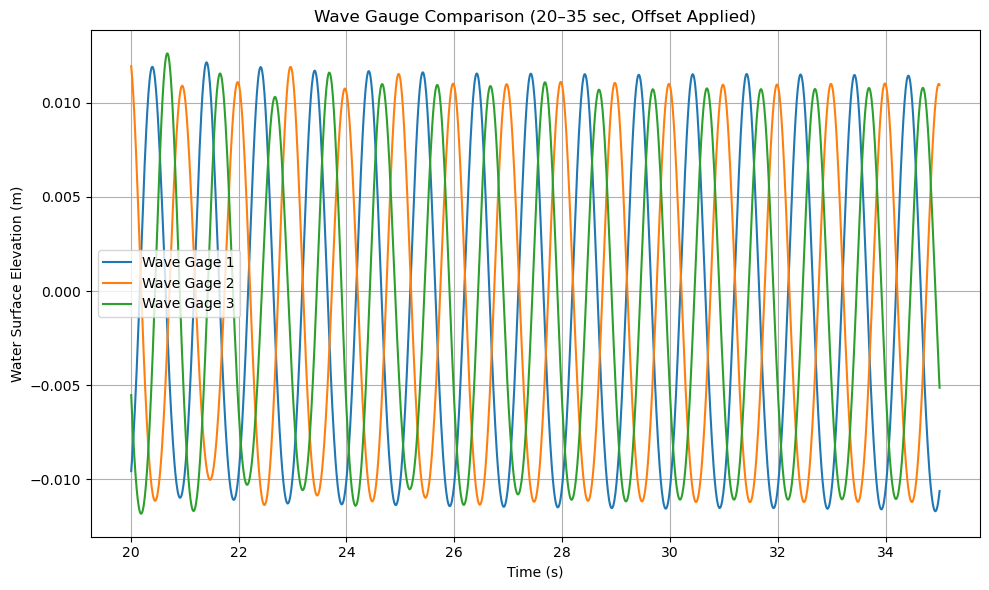

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File path
# -----------------------------
file_path = r"D:\Phd Research\CFD and Reef\WAVE_GAUGE_Flume_with_Reef_v2.xlsx"

# -----------------------------
# Read Excel file
# -----------------------------
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# -----------------------------
# Convert TIME to numeric (safe)
# -----------------------------
df["TIME"] = pd.to_numeric(df["TIME"], errors="coerce")

# -----------------------------
# Apply offset (-0.3 m)
# -----------------------------
df["WAVE GAGE 1"] = df["WAVE GAGE 1"] - 0.3
df["WAVE GAGE 2"] = df["WAVE GAGE 2"] - 0.3
df["WAVE GAGE 3"] = df["WAVE GAGE 3"] - 0.3

# -----------------------------
# Filter time range (20–35 sec)
# -----------------------------
df_filtered = df[(df["TIME"] >= 20) & (df["TIME"] <= 35)]

# -----------------------------
# Extract columns
# -----------------------------
time = df_filtered["TIME"]
wg1 = df_filtered["WAVE GAGE 1"]
wg2 = df_filtered["WAVE GAGE 2"]
wg3 = df_filtered["WAVE GAGE 3"]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(time, wg1, label="Wave Gage 1", linewidth=1.5)
plt.plot(time, wg2, label="Wave Gage 2", linewidth=1.5)
plt.plot(time, wg3, label="Wave Gage 3", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Water Surface Elevation (m)")
plt.title("Wave Gauge Comparison (20–35 sec, Offset Applied)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

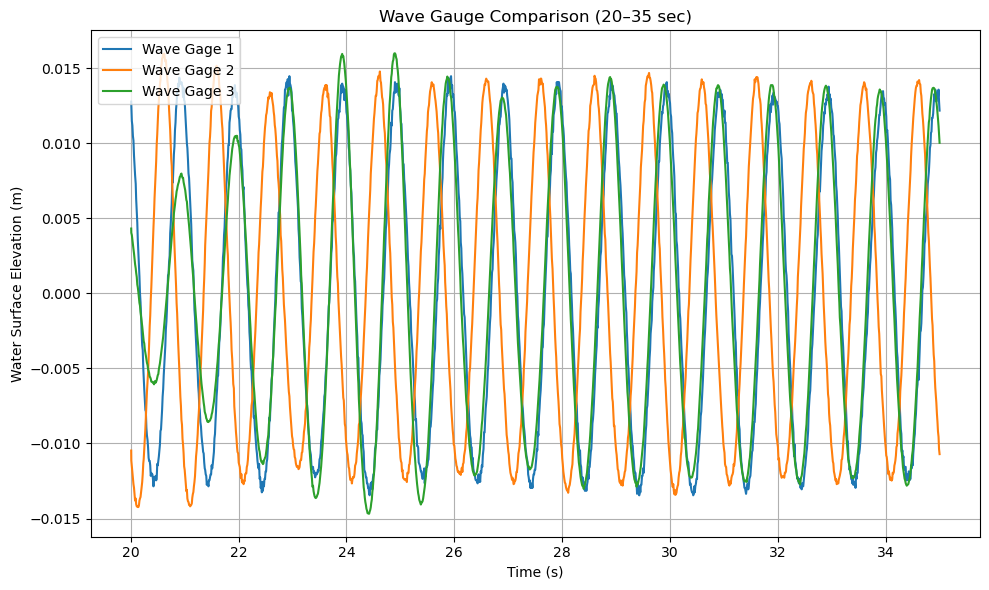

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File path
# -----------------------------
file_path = r"D:\Phd Research\CFD and Reef\From Chun Cheng Chang\WAVE GAGE DATA\converted_wave_data_St1_test1.xlsx"

# -----------------------------
# Read Excel file
# -----------------------------
df = pd.read_excel(file_path)

# -----------------------------
# Clean + rename columns
# -----------------------------
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Time (s)": "TIME",
    "Wave gauge 1 (m)": "WG1",
    "Wave gauge 2 (m)": "WG2",
    "Wave gauge 3 (m)": "WG3"
})

# -----------------------------
# Convert TIME to numeric
# -----------------------------
df["TIME"] = pd.to_numeric(df["TIME"], errors="coerce")

# -----------------------------
# Filter 20–35 sec
# -----------------------------
df_filtered = df[(df["TIME"] >= 20) & (df["TIME"] <= 35)]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(df_filtered["TIME"], df_filtered["WG1"], label="Wave Gage 1", linewidth=1.5)
plt.plot(df_filtered["TIME"], df_filtered["WG2"], label="Wave Gage 2", linewidth=1.5)
plt.plot(df_filtered["TIME"], df_filtered["WG3"], label="Wave Gage 3", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Water Surface Elevation (m)")
plt.title("Wave Gauge Comparison (20–35 sec)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()